# BEE 4311/6311: Environmental Statistics and Learning  <br> Assignment #2 (10 pts)

**Include responses to everything below in bold (including plots), and make sure your final assignment is well organized in a single markdown PDF submitted to Canvas. This makes it easier to grade (and easier to give partial credit).**

**Remember to include an acknowledgement at the bottom of this assignment if generative AI was used for coding support, including a list of the problems for which it was used.**

**Techniques and Topics:** 
- Principal component analysis
- Visualizing PCs and EOFs
- Selecting number of principal components
- Interpreting PCA

<img align="right" src="SST_map.jpg" width="600"/>

This assignment will use principal component analysis (PCA) to identify and examine patterns in global sea surface temperatures (SSTs). Fluctuations in SSTs have a profound effect on climate experienced around the world, which is why scientists are often interested in how SSTs vary in space and through time. This assignment will also focus on how SSTs in one season can be used to forecast aspects of climate (specifically air temperature) in the following season. 

1. Import the following packages: numpy, pandas, matplotlib.pyplot. Also import PCA from sklearn.decomposition. Note: you will need to import other packages further down in the assignment. 

    Download the SST_df.csv file from Canvas and load in this data as a Pandas dataframe called 'SST_df'. These data come from the National Oceanic and Atmospheric Administration's (NOAA's) Extended Reconstructed SST v5 dataset, and contain:
    - The date of monthly SST observations from 1949-10-01 through 2024-07-01 (first column)
    - A time series of SSTs (in degrees C) for 2-degree latitude by 2-degree longitude grid cells all around the world (remaining columns)

    Note: I would recommend saving the date in SST_df into a separate variable and then removing the first column of SST_df so that it only contains the SST values. 

    Also download the latitude_longitude_sst.csv file and load in this data as a Pandas dataframe called 'lat_lon'. This file contains the latitude and longitude (in decimal degrees) for every grid cell in SST_df. Note that the order of longitude and latitude values in lat_lon is aligned with the order of grid cells along the columns of SST_df. 

In [1]:
import pandas as pd
from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt

SST_df = pd.read_csv("SST_df.csv")
dates = pd.to_datetime(SST_df.iloc[:, 0])
SST_df = SST_df.iloc[:, 1:]
SST_values = SST_df.values
lat_lon = pd.read_csv("latitude_longitude_sst.csv")


2. **(1 pt) Create two maps in a 2-panel figure, one showing the long-term average of SSTs for all grid cells around the world, and the other showing the long-term standard deviation.** 
    - You can use plt.scatter to plot the longitude vs. latitude to create each map, using colors to show the statistics (mean or standard deviation) for each grid cell. 
    - Be sure to include a color bar using plt.colorbar. 
    - Please title both maps so it is clear which statistic is being shown in each. 

    **Briefly comment on:**
    - **the general locations where SSTs are warmest**
    - **the general locations where SSTs are most variable**

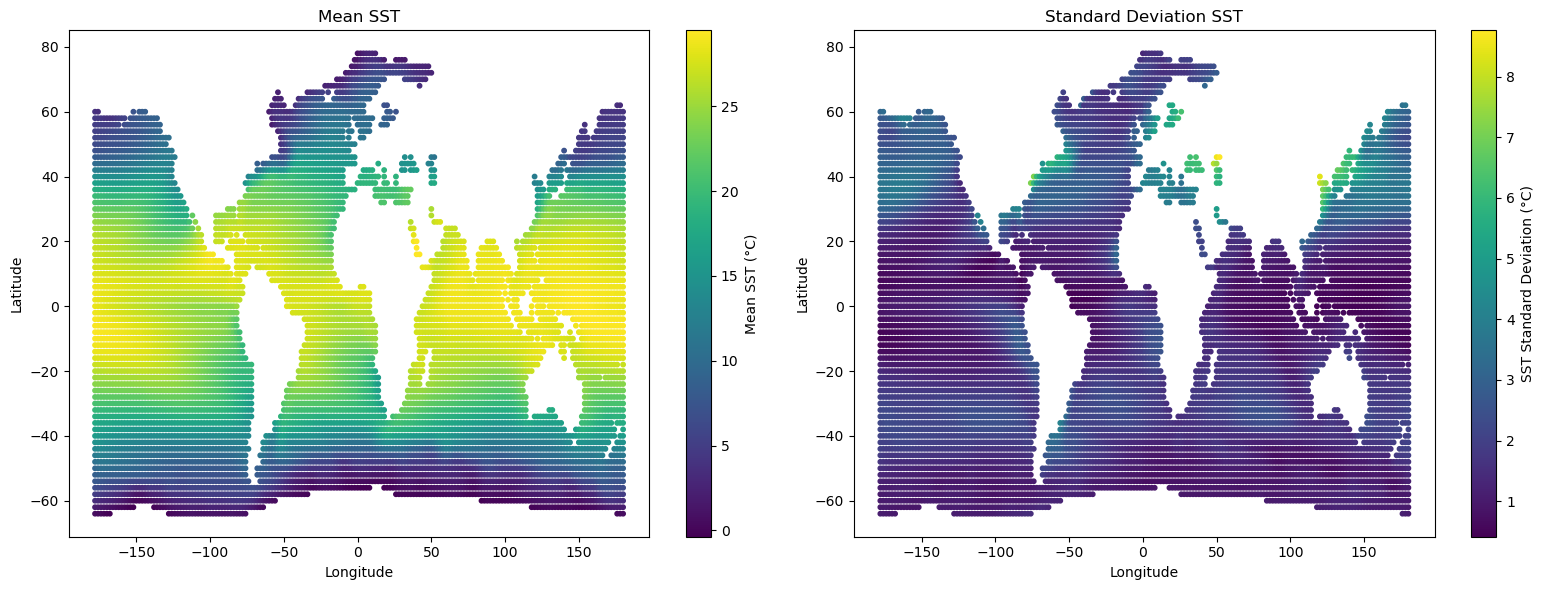

In [2]:
sst_mean = SST_df.mean(axis=0)
sst_std  = SST_df.std(axis=0)
lon = lat_lon['lon']
lat = lat_lon['lat']

plt.figure(figsize=(16,6))
plt.subplot(1,2,1)
sc1 = plt.scatter(lon, lat, c=sst_mean, s=10)
plt.colorbar(sc1, label='Mean SST (°C)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Mean SST')

plt.subplot(1,2,2)
sc2 = plt.scatter(lon, lat, c=sst_std, s=10)
plt.colorbar(sc2, label='SST Standard Deviation (°C)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Standard Deviation SST')

plt.tight_layout()
plt.show()

#### Answer 2
- Warmest places for SST:
  The warmest SST are located in the tropical regions near the equator (-20 $\degree$ S - 20 $\degree$ N).
- Most variable places for SST:
  The most variable places for SST are located around 40 $\degree$ N, especially in regions such as the North Pacific and North Atlantic Oceans.

3. **(1 pt)** In this problem you will apply PCA to the SST data in SST_df and examine the results. First, fit PCA to your data and extract the explained variance for different PCs.

    **(a) Create a barplot of the explained variance for the first 10 PCs, being sure to label all axes. How much variance is explained by the first PC?**

    **(b) Next, extract the loadings associated with the first EOF and create a map showing these loadings across the global oceans.** 
    - You can use a similar approach as in problem #2 to create this map, with colors used to represent the loading values. 
    - However, here I have provided starter code to specify a custom color mapping (blue-to-red) that will improve map readability.
    - You will also want to specify the minimum and maximum values for the color scale using vmin and vmax (see starter code)

    **(c) Finally, plot the time series of the first PC, being sure to label all axes.**

    **(d) Based on the results from these three figures, briefly explain/interpret what the first PC represents in the SST dataset, and justify your answer.** 

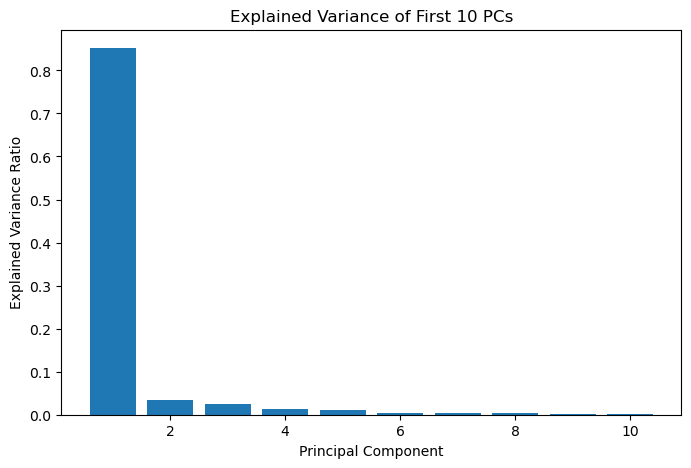

Variance explained by PC1: 0.8518903343976777


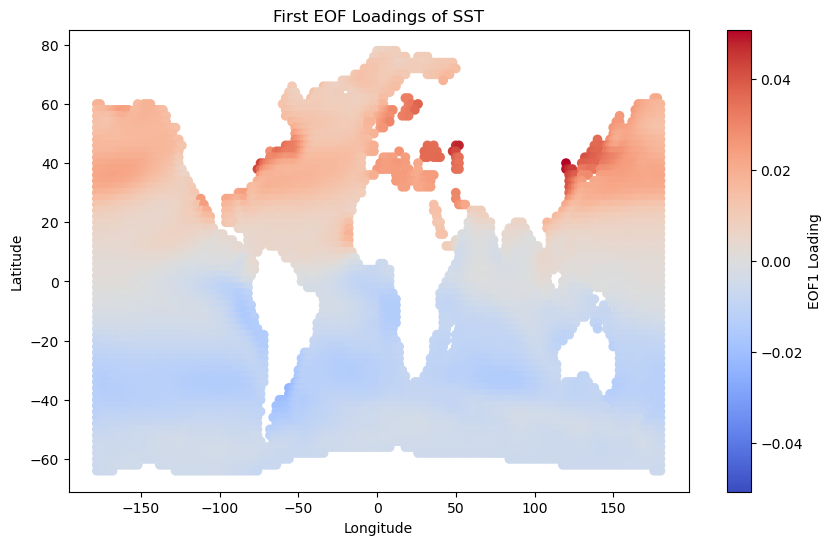

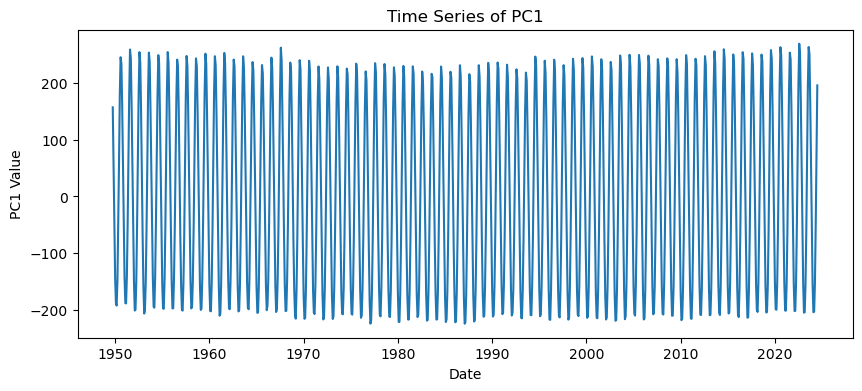

In [3]:
# Define the custom colormap
from matplotlib import colors as mcolors
colors = ['blue', 'lightgrey', 'red']  # Color transitions
n_bins = 100  # Number of bins for the colormap
cmap_name = 'custom_blue_white_red'
custom_cmap = mcolors.LinearSegmentedColormap.from_list(cmap_name, colors, N=n_bins)
##use like this: plt.scatter(...,cmap=custom_cmap,vmin=,vmax=)

pca = PCA()
pca.fit(SST_values)
explained_variance = pca.explained_variance_ratio_

# a: explained variance
plt.figure(figsize=(8,5))
pcs = np.arange(1, 11)
plt.bar(pcs, explained_variance[:10])
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.title("Explained Variance of First 10 PCs")
plt.show()
print("Variance explained by PC1:", explained_variance[0])

# b: first EOF
# Extract loadings for the first EOF
EOF1 = pca.components_[0]
cmap = plt.cm.coolwarm
plt.figure(figsize=(10,6))
sc = plt.scatter(
    lon, lat,c=EOF1,cmap=cmap,vmin=-np.max(np.abs(EOF1)),vmax=np.max(np.abs(EOF1)))
plt.colorbar(sc, label="EOF1 Loading")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("First EOF Loadings of SST")
plt.show()

# c: time series of EOF1
PCs = pca.transform(SST_values)
PC1 = PCs[:,0]
plt.figure(figsize=(10,4))
plt.plot(dates, PC1)
plt.xlabel("Date")
plt.ylabel("PC1 Value")
plt.title("Time Series of PC1")
plt.show()


#### Answer3
The first PC explains about 85% of the variance among the first 10 principal components, indicating that it represents the dominant pattern of SST variability in the dataset. The first EOF map shows a clear spatial pattern, where SSTs tend to increase in the Northern Hemisphere and decrease in parts of the Southern Hemisphere, indicating that this contrast is the main source of spatial variability.

The time series of PC1 shows that most years have relatively high PC1 values, suggesting that the spatial pattern represented by PC1 occurs frequently over time. Therefore, the first PC captures the primary large-scale spatial pattern of SST variability across the global oceans, with strong contributions from differences between northern and southern ocean regions.

4. **(1 pt)** (a) Re-apply PCA to the SST data as in problem (3), but this time, first center and scale the data for each grid cell using the StandardScalar from sklearn.preprocessing. 

    **(b) As in problem (3), extract the loadings associated with the first EOF and create a map showing these loadings across the global oceans.** 

    **(3) Compare your map of loadings from this problem and problem (3). What is the largest difference? Why do you think this difference emerges? (hint: look at your results from problem (2))** 

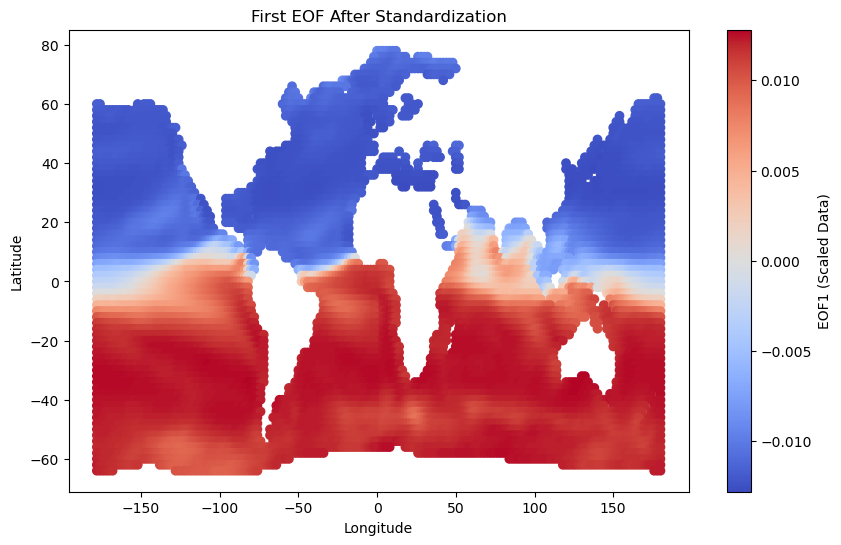

In [4]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
SST_scaled = scaler.fit_transform(SST_values)
pca_scaled = PCA()
pca_scaled.fit(SST_scaled)
EOF1_scaled = pca_scaled.components_[0]
plt.figure(figsize=(10,6))

sc = plt.scatter(
    lon, lat,
    c=EOF1_scaled,
    cmap="coolwarm",
    vmin=-np.max(np.abs(EOF1_scaled)),
    vmax=np.max(np.abs(EOF1_scaled))
)

plt.colorbar(sc, label="EOF1 (Scaled Data)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("First EOF After Standardization")

plt.show()

#### Answer4
The increase trends in high-latitude become more pronounced than the tropical regions. The reason is the tropical regions have higher absolute SST values and larger absolute variability, which dominate the PCA results. As a result, the spatial patterns in higher latitudes are less visible.

After applying standardization, each grid cell is scaled to have the same mean and standard deviation. Therefore, the high-latitude regions contribute more equally to the PCA and variance become more apparent.

5. **(1 pt)** We will now focus on SST standardized anomalies (standardized differences from long-term average conditions) during a specific season (late fall - early winter). 

    (a) First, create a new version of SST_df (called sst_df_standardized) in which the data for each grid cell are centered around the long-term average and divided by the standard deviation for each calendar month. That is: 
    - for a given grid cell and calendar month, find the long-term average SST for that grid cell and month (12 values, one for Jan, one for Feb, etc.), and similarly, find the long-term standard deviation. 
    - Then, for the monthly SSTs of that grid cell, subtract the monthly means and divide by the monthly standard deviations (i.e., subtract the mean January value from all January SSTs, and then divide the difference by the standard deviation for January; do the same for all months). 
    - Repeat this process for all grid cells. 
    - The result will be a matrix of monthly SST standardized anomalies. 

    (b) Next, for each calendar year (from 1949 through 2023), calculate the 3-month rolling average of monthly standardized anomalies for October, November, and December (OND) of that year. There should be a single OND anomaly value for each year for each grid cell. Place these annual OND anomaly values in a dataframe called sst_df_standardized_OND.  
    
    **(c) Plot the time series of OND anomaly values against years for the grid cell at longitude = -100 and latitude = 0 (a location in the middle of the equatorial Pacific Ocean).**

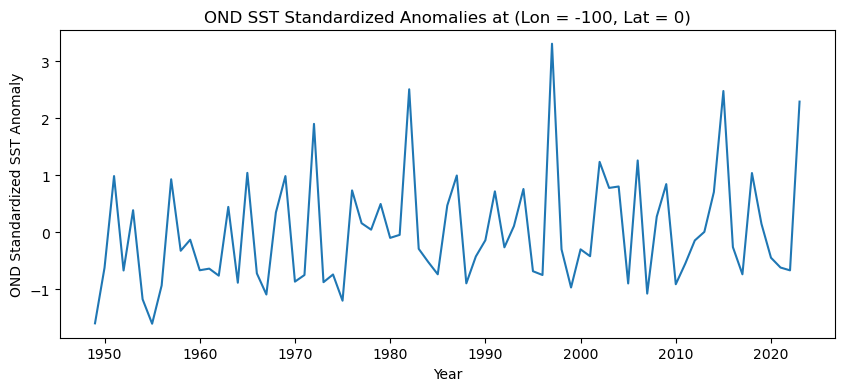

In [ ]:
# ---- (a) Monthly standardized anomalies ----

# Create working dataframe
sst = SST_df.copy()
sst['date'] = dates
sst['month'] = sst['date'].dt.month

# Keep ONLY SST values for calculations
sst_values = sst.drop(columns=['date','month'])

# Monthly climatology (mean & std for each grid cell and month)
monthly_mean = sst_values.groupby(sst['month']).transform('mean')
monthly_std = sst_values.groupby(sst['month']).transform('std')

# Standardized anomalies
sst_standardized = (sst_values - monthly_mean) / monthly_std
sst_standardized['date'] = dates
sst_standardized['year'] = sst_standardized['date'].dt.year
sst_standardized['month'] = sst_standardized['date'].dt.month

# ---- (b) Compute OND averages ----
ond_data = sst_standardized[sst_standardized['month'].isin([10,11,12])]
sst_df_standardized_OND = ond_data.groupby('year').mean()

# ---- (c) Extract and plot time series ----
target_idx = ((lat_lon['lon'] + 100)**2 + (lat_lon['lat'] - 0)**2).idxmin()
ond_series = sst_df_standardized_OND.iloc[:, target_idx]
# Plot
plt.figure(figsize=(10,4))
plt.plot(sst_df_standardized_OND.index, ond_series)
plt.xlabel("Year")
plt.ylabel("OND Standardized SST Anomaly")
plt.title("OND SST Standardized Anomalies at (Lon = -100, Lat = 0)")
plt.show()

6. **(1 pt) (a) Apply PCA to the data in SST_df_standardized_OND and create a barplot of the eigenvalues for the first 10 PCs (rather than explained variance), being sure to label all axes. Include +/- 1 standard errors for these eigenvalues, following North's Rule. How many PCs do you think are worth further examination based on this result? Justify your choice.**

    **(b) For the number of PCs you selected, extract the loadings of the associated EOFs and create a map showing these loadings across the global oceans.** 
    - Follow a similiar approach as in problem (3) to create these maps. 

    **(c) Briefly describe the most prominant spatial pattern observed in each of the EOFs selected. Can you interpret what physical processes these patterns represent?**
    - If you are not familiar with climate science, the interpretation may be difficult, so ask a classmate or me. 

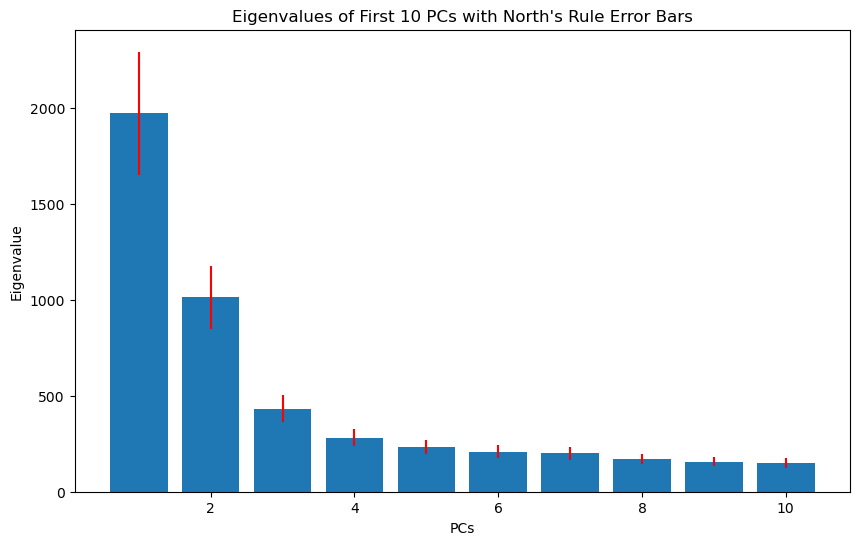

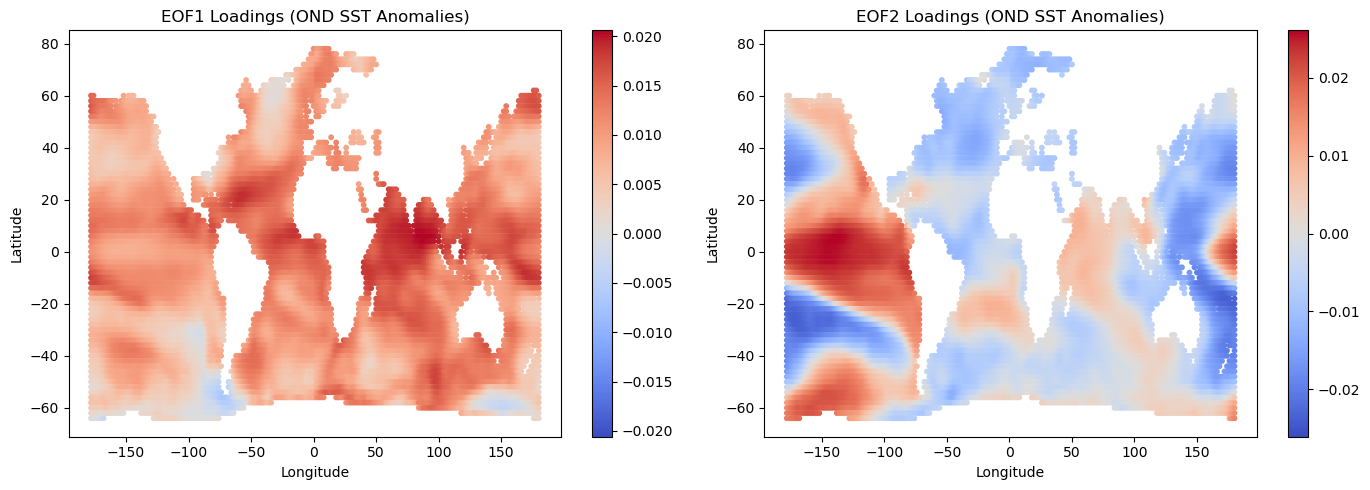

In [11]:
sst_df_standardized_OND = sst_df_standardized_OND.drop(columns=['date','month'])
X = sst_df_standardized_OND.values
pca = PCA()
pca.fit(X)

eigenvalues = pca.explained_variance_
N = X.shape[0]
eig_std = eigenvalues * np.sqrt(2 / N)
plt.figure(figsize=(10,6))
pcs = np.arange(1,11)
plt.bar(pcs, eigenvalues[:10])
plt.errorbar(pcs, eigenvalues[:10], yerr=eig_std[:10], fmt='none',color='r')
plt.xlabel("PCs")
plt.ylabel("Eigenvalue")
plt.title("Eigenvalues of First 10 PCs with North's Rule Error Bars")
plt.show()


# b: plot EOF
EOF1 = pca.components_[0]
EOF2 = pca.components_[1]
plt.figure(figsize=(14,5))
# EOF1
plt.subplot(1,2,1)
sc1 = plt.scatter(
    lon, lat,
    c=EOF1,
    cmap='coolwarm',
    vmin=-np.max(np.abs(EOF1)),
    vmax=np.max(np.abs(EOF1)),
    s=10
)
plt.colorbar(sc1)
plt.title("EOF1 Loadings (OND SST Anomalies)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

# EOF2
plt.subplot(1,2,2)
sc2 = plt.scatter(
    lon, lat,
    c=EOF2,
    cmap='coolwarm',
    vmin=-np.max(np.abs(EOF2)),
    vmax=np.max(np.abs(EOF2)),
    s=10
)
plt.colorbar(sc2)
plt.title("EOF2 Loadings (OND SST Anomalies)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.tight_layout()
plt.show()

#### Answer 6a
I think the first two PCs are worth to be reserved. Since they explain a relatively large proportion of the total variance, and their error bars based on North’s rule are relatively small.

#### Answer 6c
In the first EOF pattern, most regions show anomalies with the same sign across large areas of the global oceans, indicating a large-scale coherent SST variability pattern.

In the second EOF pattern, there is a strong signal in the equatorial Pacific Ocean, with obvious SST anomalies in this region. This spatial pattern is consistent with the El Niño–Southern Oscillation (ENSO). During El Niño events, SSTs become warmer in the eastern and central Pacific Ocean, which corresponds to positive values in this EOF pattern.

7. **(1 pt) In the first 2 panels of a 3-panel figure, plot the time series of the selected PCs from problem (6) derived from the SST_df_standardized_OND dataset. Be sure to label all axes.** 

    **Then, in the third panel, plot the time series of OND anomaly values against years for the grid cell at longitude = -100 and latitude = 0 (as you did in problem (5)).**
    
    **Finally, use the synthesis equation to estimate the OND anomaly values for this grid cell based on the PCs you selected from problem (6). Add these estimated values as another line in the third panel. Briefly comment on how well you were able to reconstruct the OND anomaly values at this grid cell with the PCs you selected.** 

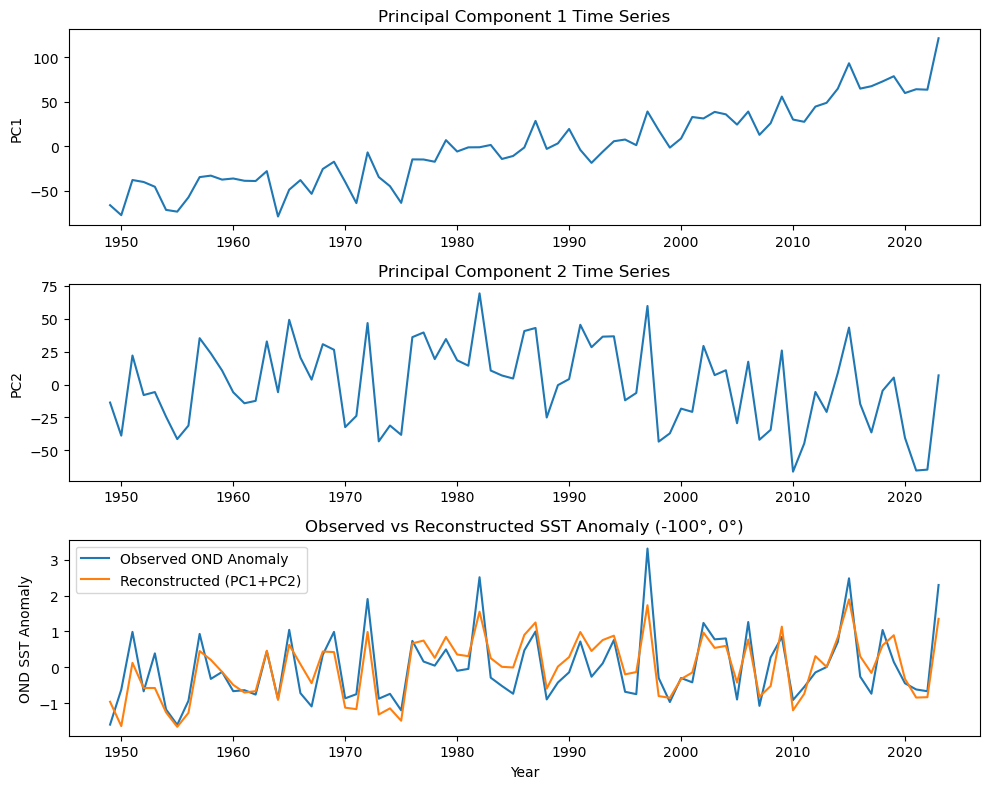

In [12]:
PC_scores = pca.transform(X)
PC1 = PC_scores[:,0]
PC2 = PC_scores[:,1]
years = sst_df_standardized_OND.index

target = lat_lon[(lat_lon['lon'] == -100) & (lat_lon['lat'] == 0)]
grid_index = target.index[0]
obs_series = sst_df_standardized_OND.iloc[:, grid_index]

EOF1 = pca.components_[0]
EOF2 = pca.components_[1]
# Reconstructed anomaly using first 2 PCs
reconstructed = PC1 * EOF1[grid_index] + PC2 * EOF2[grid_index]

# plot figures
plt.figure(figsize=(10,8))
plt.subplot(3,1,1)
plt.plot(years, PC1)
plt.ylabel("PC1")
plt.title("Principal Component 1 Time Series")
plt.subplot(3,1,2)
plt.plot(years, PC2)
plt.ylabel("PC2")
plt.title("Principal Component 2 Time Series")
plt.subplot(3,1,3)
plt.plot(years, obs_series, label="Observed OND Anomaly")
plt.plot(years, reconstructed, label="Reconstructed (PC1+PC2)")
plt.xlabel("Year")
plt.ylabel("OND SST Anomaly")
plt.title("Observed vs Reconstructed SST Anomaly (-100°, 0°)")
plt.legend()
plt.tight_layout()
plt.show()

#### Answer7
The trend of reconstructed time series generally follow the main variability trend of the observed time series. However, the reconstructed series appears smoother and exhibits smaller peak amplitudes compared to the observed data, due to the missing information stored in other PCs.

8. **(2 pt)** In this problem you will use the selected PCs from problem (6) to build a forecasting model that predicts air temperatures over land around the world. 

    (a) First, download the air_temp_df.csv file from Canvas and load in this data as a Pandas dataframe called 'air_temp_df'. These data come from NOAA's Global Surface Temperature dataset and contain:
    - The date of monthly air temperature observations over land from 1950-01-01 through 2024-07-01 (first column)
    - A time series of surface air temperatures (in degrees C) for 5-degree latitude by 5-degree longitude grid cells over the world's land masses (remaining columns)
    - Note: As before, I would recommend saving the date in air_temp_df into a separate variable and then removing the first column of air_temp_df so that it only contains the air temperature values. 

    (b) Also download the latitude_longitude_air_temp.csv file and load in this data as a Pandas dataframe called 'lat_lon_air_temp'. This file contains the latitude and longitude (in decimal degrees) for every grid cell in air_temp_df. Note that the order of longitude and latitude values in lat_lon_air_temp is aligned with the order of grid cells along the columns of air_temp_df. 

    (c) Once you have downloaded and loaded in these data, create a matrix of annual air temperature standardized anomalies for January, February, and March (JFM), called air_temp_df_standardized_JFM, in the same way you made the annual SST standardized anomaly matrix (sst_df_standardized_OND) for SSTs between October-December. Note that the JFM air temperature values occur in the season following the OND SST anomaly values, allowing us to assess whether the OND SST anomaly values can be used to forecast global air temperatures in the following three-month period. 

    (d) For each grid cell in air_temp_df_standardized_JFM, regress the temperature anomaly values again the PCs of sst_df_standardized_OND you selected in problem (6). Save the R-squared value for each air temperature grid cell. 
    
    **(e) Finally, create a map of these R-squared values across the world's land masses. In which continents are JFM air temperature anomalies most predictable based on the PCs of SST anomalies from the preceding OND season?**

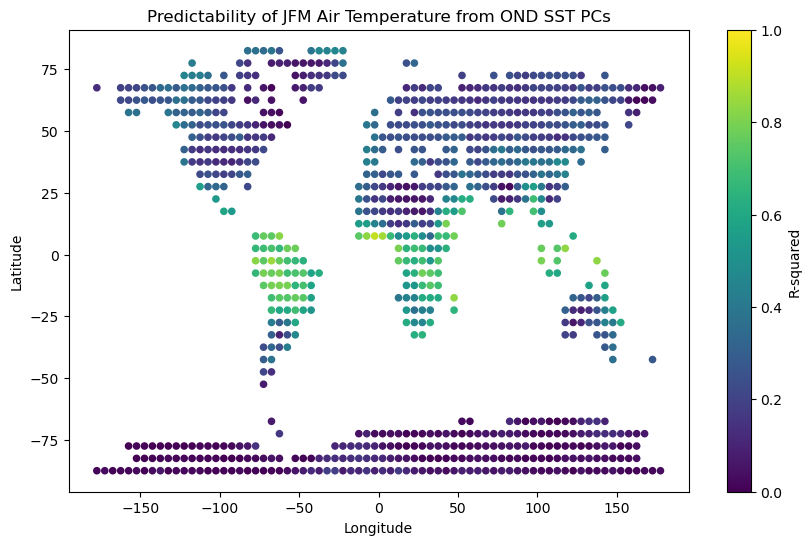

In [13]:
from sklearn.linear_model import LinearRegression

air_temp_df = pd.read_csv("air_temp_df.csv")
air_dates = pd.to_datetime(air_temp_df.iloc[:,0])
air_temp_df = air_temp_df.iloc[:,1:]

latlon_air = pd.read_csv("latitude_longitude_air_temp.csv")
lon_air = latlon_air['lon']
lat_air = latlon_air['lat']

air = air_temp_df.copy()
air['date'] = air_dates
air['year'] = air['date'].dt.year
air['month'] = air['date'].dt.month
monthly_mean = air_temp_df.groupby(air['month']).transform('mean')
monthly_std = air_temp_df.groupby(air['month']).transform('std')
air_standardized = (air_temp_df - monthly_mean) / monthly_std
air_standardized['date'] = air_dates
air_standardized['year'] = air_dates.dt.year
air_standardized['month'] = air_dates.dt.month

jfm_data = air_standardized[air_standardized['month'].isin([1,2,3])]
air_temp_JFM = jfm_data.groupby('year').mean()
air_temp_df_standardized_JFM = air_temp_JFM.drop(columns=['month','date'])

# Predictor matrix (SST PCs)
X_SST = np.column_stack([PC1, PC2])
Y_SST = air_temp_df_standardized_JFM.values
n_cells = Y_SST.shape[1]
R2_values = np.zeros(n_cells)
for i in range(n_cells):
    y_SST = Y_SST[:, i]
    model = LinearRegression()
    model.fit(X_SST, y_SST)
    R2_values[i] = model.score(X_SST, y_SST)

# plot
plt.figure(figsize=(10,6))
sc = plt.scatter(
    lon_air,
    lat_air,
    c=R2_values,
    cmap="viridis",
    vmin=0,
    vmax=1,
    s=20
)
plt.colorbar(sc, label="R-squared")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Predictability of JFM Air Temperature from OND SST PCs")
plt.show()

#### Answer8
Tropical and subtropical regions, such as the southern part of South America, northern Africa, and southern Asia, appear to be more predictable. In these regions, atmospheric circulation patterns are strongly linked to Pacific SST anomalies. 

9. (**1 pt)** In this problem, you will rotate the first two EOFs for the standardized OND SST data, and compare these rotated EOFs to the original EOFs.
    (a) First, you'll need to install the factor_analyzer package into your Anaconda base environment. If you get stuck here, it could be helpful to ask ChatGPT for help on how to do this. 

    (b) Then, from factor_analyzer, import Rotator (from factor_analyzer import Rotator)

    (c) using the Rotator function, apply varimax rotation to the first two EOFs for the standardized OND SST data

    **(d) Create a 2X2 panel of figures, where on the left column, you plot maps of the loadings associated with the original EOFs, and in the right column, you plot maps of the loadings associated with the rotated EOFs.**

    **(e) Comment on the largest difference you see between the original and rotated EOFs.**


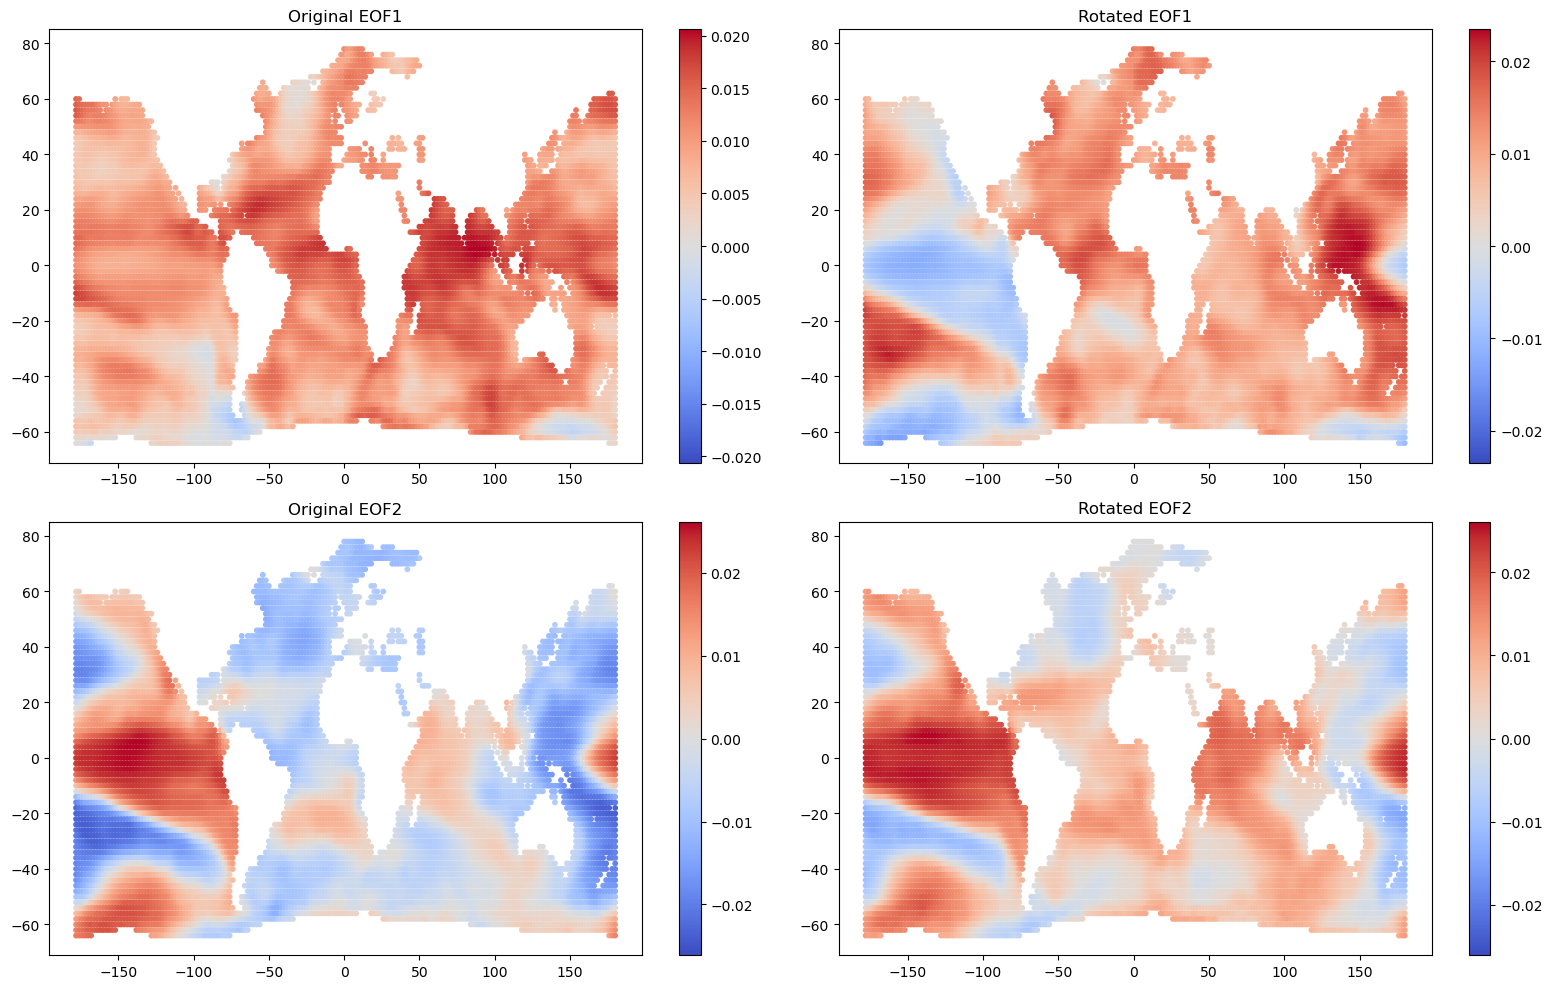

In [14]:
from factor_analyzer import Rotator

EOFs = pca.components_[0:2].T   # shape: (grid_cells, 2)

# Apply varimax rotation
rotator = Rotator(method='varimax')
rotated_EOFs = rotator.fit_transform(EOFs)
EOF1_rot = rotated_EOFs[:,0]
EOF2_rot = rotated_EOFs[:,1]

plt.figure(figsize=(16,10))
plt.subplot(2,2,1)
sc1 = plt.scatter(lon, lat, c=EOF1, cmap='coolwarm',
                  vmin=-np.max(np.abs(EOF1)), vmax=np.max(np.abs(EOF1)), s=10)
plt.colorbar(sc1)
plt.title("Original EOF1")
plt.subplot(2,2,2)
sc2 = plt.scatter(lon, lat, c=EOF1_rot, cmap='coolwarm',
                  vmin=-np.max(np.abs(EOF1_rot)), vmax=np.max(np.abs(EOF1_rot)), s=10)
plt.colorbar(sc2)
plt.title("Rotated EOF1")
plt.subplot(2,2,3)
sc3 = plt.scatter(lon, lat, c=EOF2, cmap='coolwarm',
                  vmin=-np.max(np.abs(EOF2)), vmax=np.max(np.abs(EOF2)), s=10)
plt.colorbar(sc3)
plt.title("Original EOF2")
plt.subplot(2,2,4)
sc4 = plt.scatter(lon, lat, c=EOF2_rot, cmap='coolwarm',
                  vmin=-np.max(np.abs(EOF2_rot)), vmax=np.max(np.abs(EOF2_rot)), s=10)
plt.colorbar(sc4)
plt.title("Rotated EOF2")

plt.tight_layout()
plt.show()

#### Answer9
For the first EOF, after rotation, the region of Eastern Pacific no longer shows a positive pattern. Compared with the original EOF, the spatial pattern becomes less globally uniform.

For the second EOF, the central Pacific region shows more pronounced positive values, making the ENSO spatial pattern more clearly identifiable after rotation.

10. **(1 pt)** In this problem you will take your dataset of standardized SST anomalies for OND, and you will explore the structure of these anomalies in the tropics using Multidimensional Scaling (MDS) and Jaccard distances.

    (a) Convert SST anomalies into a binary matrix. Transform sst_df_standardized_OND into a binary matrix:
        1 for a positive anomaly;
        0 for a negative anomaly
    
    (b) Isolate tropical SSTs: 
        Select only the grid points (columns) with latitude between -20° and 20°;
        Create a new DataFrame containing only these tropical columns.

    (c) Compute pairwise Jaccard distances and perform MDS: 
        Use scipy.spatial.distance.pdist with metric='jaccard' to compute pairwise distances between years (rows); 
        Convert the condensed distance matrix to square form with scipy.spatial.distance.squareform; 
        Apply MDS from sklearn.manifold using dissimilarity='precomputed' to obtain a 2D representation of the years.

    (d) Identify the two most anomalous years
    -   **Plot the MDS coordinates of all years (scatter plot).**
    - **Identify the two years that are most separated from the cluster along the MDS1 axis in both the positive and negative direction along that axis.**
    - **Count and report the number of positive and negative anomalies in the binary data for these “outlier” years. What do you think makes these years anomalous? What do you think makes the data for these years difference (i.e., why are they situated on different sides of the MDS1 axis)?**

/Users/yingyingliu/opt/anaconda3/envs/data/lib/python3.12/site-packages/sklearn/manifold/_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
/Users/yingyingliu/opt/anaconda3/envs/data/lib/python3.12/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
/Users/yingyingliu/opt/anaconda3/envs/data/lib/python3.12/site-packages/sklearn/manifold/_mds.py:771: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(


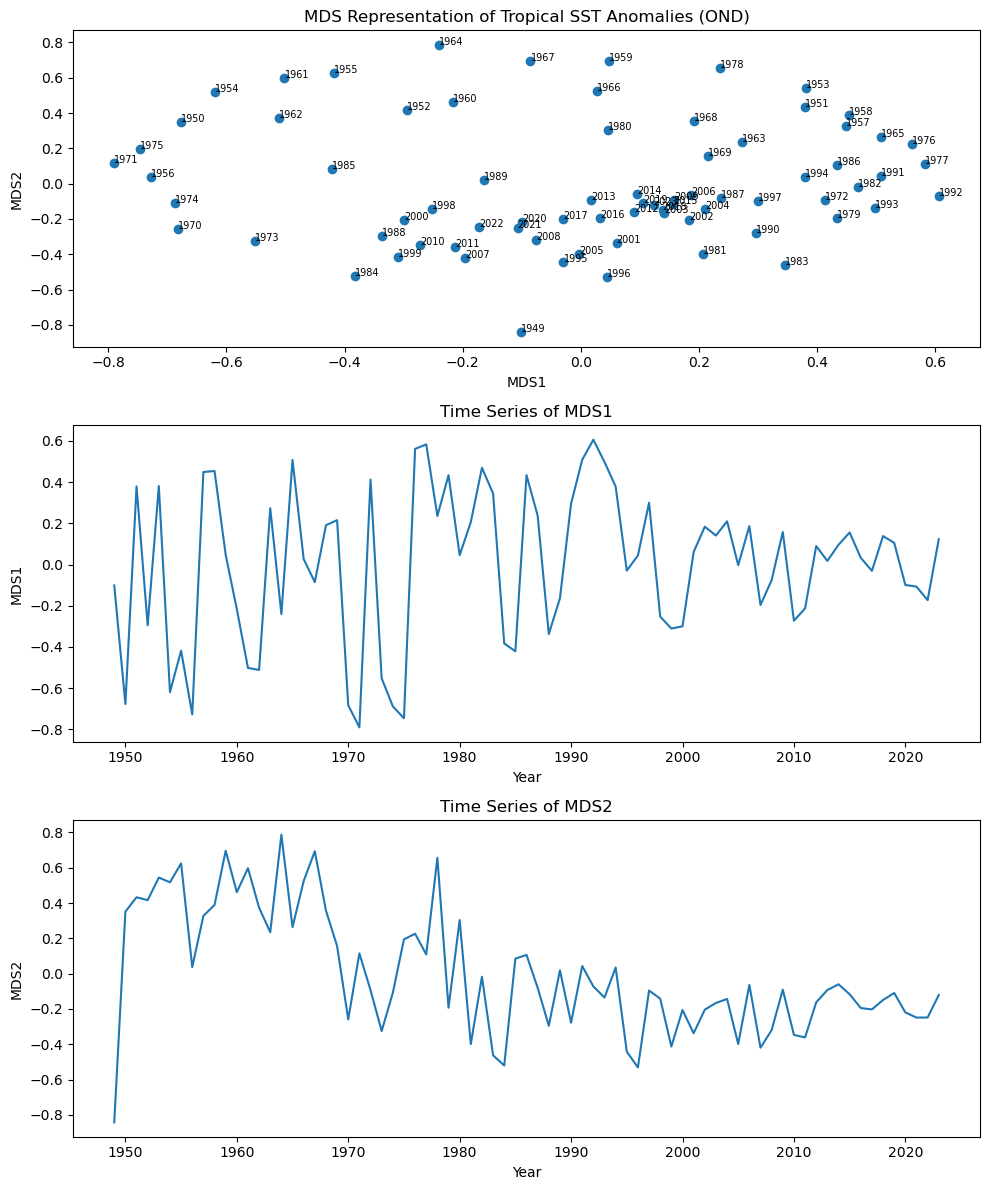

Most positive MDS1 year: 1992
Most negative MDS1 year: 1971
Year 1992 positive anomalies: 1143 negative: 1716
Year 1971 positive anomalies: 162 negative: 2697


In [17]:
from scipy.spatial.distance import pdist, squareform
from sklearn.manifold import MDS

sst_binary = (sst_df_standardized_OND > 0).astype(int)
tropical_mask = (lat_lon['lat'] >= -20) & (lat_lon['lat'] <= 20)
sst_binary_tropics = sst_binary.loc[:, tropical_mask.values]

dist_condensed = pdist(sst_binary_tropics.values, metric='jaccard')
dist_matrix = squareform(dist_condensed)
mds = MDS(n_components=2, dissimilarity='precomputed', random_state=42)
mds_coords = mds.fit_transform(dist_matrix)
MDS1 = mds_coords[:,0]
MDS2 = mds_coords[:,1]
years = sst_binary_tropics.index

plt.figure(figsize=(10,12))
plt.subplot(3,1,1)
plt.scatter(MDS1, MDS2)
plt.xlabel("MDS1")
plt.ylabel("MDS2")
for i, year in enumerate(years):
    plt.text(MDS1[i], MDS2[i], str(year), fontsize=7)
plt.title("MDS Representation of Tropical SST Anomalies (OND)")
years = sst_binary_tropics.index 
plt.subplot(3,1,2)
plt.plot(years, mds_coords[:,0])
plt.xlabel("Year")
plt.ylabel("MDS1")
plt.title("Time Series of MDS1")
plt.subplot(3,1,3)
plt.plot(years, mds_coords[:,1])
plt.xlabel("Year")
plt.ylabel("MDS2")
plt.title("Time Series of MDS2")
plt.tight_layout()
plt.show()

year_pos = years[np.argmax(MDS1)]
year_neg = years[np.argmin(MDS1)]
print("Most positive MDS1 year:", year_pos)
print("Most negative MDS1 year:", year_neg)

row_pos = sst_binary_tropics.loc[year_pos]
row_neg = sst_binary_tropics.loc[year_neg]
pos_count_pos = (row_pos == 1).sum()
neg_count_pos = (row_pos == 0).sum()
pos_count_neg = (row_neg == 1).sum()
neg_count_neg = (row_neg == 0).sum()
print("Year", year_pos, "positive anomalies:", pos_count_pos, "negative:", neg_count_pos)
print("Year", year_neg, "positive anomalies:", pos_count_neg, "negative:", neg_count_neg)

#### Answer10
The most positive year is 1992 and the most negative year is 1971.

In year 1992, 1143 times of positive anomalies and 1716 times of negative anomalies. In year 1971, 162 times of positive anomalies and 2697 times of negative anomalies.

These anomalous years are associated with ENSO events. During El Niño years, large areas of the tropical Pacific experience positive SST anomalies (Year 1992), while during La Niña years, the tropical Pacific tends to have widespread negative anomalies (Year 1971). Because the binary anomaly patterns differ strongly between these events, the Jaccard distance places them on opposite sides of the MDS1 axis.